
# Comparación de DE-COP, SimMIA y DUALTEST

Este notebook mantiene la estructura del análisis original y agrega manualmente los resultados de DUALTEST.

La comparación principal se realiza sobre **BookTection comparison**, porque es el conjunto comparable con los resultados de DE-COP y SimMIA. Al final se muestran además los resultados de DUALTEST sobre WikiMIA y BookTection + SAGE.


In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Directorios
# ---------------------------------------------------------

# El notebook está dentro de una carpeta del proyecto.
# results y figures se encuentran dentro de PROJECT_ROOT.
PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)


PROJECT_ROOT: c:\Users\isiva\OneDrive\Escritorio\Ingenieria de software\NLP_Proyecto_Final\simmia_decop
RESULTS_DIR: c:\Users\isiva\OneDrive\Escritorio\Ingenieria de software\NLP_Proyecto_Final\simmia_decop\results
FIGURES_DIR: c:\Users\isiva\OneDrive\Escritorio\Ingenieria de software\NLP_Proyecto_Final\simmia_decop\figures


## Carga de resultados de DE-COP y SimMIA

In [2]:

# ---------------------------------------------------------
# Cargar métricas de DE-COP y SimMIA
# ---------------------------------------------------------

decop_70 = pd.read_csv(
    RESULTS_DIR
    / "decop"
    / "llama-3.3-70b-versatile"
    / "decop_metrics_summary.csv"
).iloc[0]

decop_8 = pd.read_csv(
    RESULTS_DIR
    / "decop"
    / "llama-3.1-8b-instant"
    / "decop_metrics_summary.csv"
).iloc[0]

simmia_70 = pd.read_csv(
    RESULTS_DIR
    / "simmia"
    / "llama-3.3-70b-versatile"
    / "simmia_metrics_summary.csv"
).iloc[0]

simmia_8 = pd.read_csv(
    RESULTS_DIR
    / "simmia"
    / "llama-3.1-8b-instant"
    / "simmia_metrics_summary.csv"
).iloc[0]

print("Resultados cargados correctamente.")


Resultados cargados correctamente.


## Resultados de DUALTEST cargados manualmente

In [3]:

# ---------------------------------------------------------
# Resultados DUALTEST hardcodeados
# ---------------------------------------------------------

dualtest_results = pd.DataFrame([
    {
        "experiment": "wikimia_llama33_70b",
        "dataset_group": "WikiMIA",
        "model_group": "Llama 3.3 70B",
        "n": 82,
        "mae": 0.4624267575582549,
        "brier": 0.25077985125897123,
        "log_loss": 0.721102696209566,
        "roc_auc": 0.5597722960151803,
        "pr_auc": 0.645186682307294,
    },
    {
        "experiment": "wikimia_llama31_8b",
        "dataset_group": "WikiMIA",
        "model_group": "Llama 3.1 8B",
        "n": 82,
        "mae": 0.46821759366198956,
        "brier": 0.2468025897552878,
        "log_loss": 0.6892327366370498,
        "roc_auc": 0.5404807084123973,
        "pr_auc": 0.6661131817971966,
    },
    {
        "experiment": "booktection_comparison_llama33_70b",
        "dataset_group": "BookTection comparison",
        "model_group": "Llama 3.3 70B",
        "n": 200,
        "mae": 0.4750359442740262,
        "brier": 0.2359774949529504,
        "log_loss": 0.6640343548026051,
        "roc_auc": 0.6639,
        "pr_auc": 0.6602412553518664,
    },
    {
        "experiment": "booktection_sage_llama33_70b",
        "dataset_group": "BookTection + SAGE",
        "model_group": "Llama 3.3 70B",
        "n": 200,
        "mae": 0.4760222169184361,
        "brier": 0.2372786330704929,
        "log_loss": 0.6676564553715744,
        "roc_auc": 0.62765,
        "pr_auc": 0.6341642330679841,
    },
    {
        "experiment": "booktection_comparison_llama31_8b",
        "dataset_group": "BookTection comparison",
        "model_group": "Llama 3.1 8B",
        "n": 200,
        "mae": 0.47783682586335013,
        "brier": 0.23366099874069718,
        "log_loss": 0.6582126666121121,
        "roc_auc": 0.668,
        "pr_auc": 0.6781954407982133,
    },
    {
        "experiment": "booktection_sage_llama31_8b",
        "dataset_group": "BookTection + SAGE",
        "model_group": "Llama 3.1 8B",
        "n": 200,
        "mae": 0.4982697012732234,
        "brier": 0.25185578686111404,
        "log_loss": 0.6977669510804548,
        "roc_auc": 0.57695,
        "pr_auc": 0.548910545560691,
    },
])

display(dualtest_results)


,experiment,dataset_group,model_group,n,mae,brier,log_loss,roc_auc,pr_auc
0,wikimia_llama33_70b,WikiMIA,Llama 3.3 70B,82,0.462427,0.250780,0.721103,0.559772,0.645187
1,wikimia_llama31_8b,WikiMIA,Llama 3.1 8B,82,0.468218,0.246803,0.689233,0.540481,0.666113
2,booktection_comparison_llama33_70b,BookTection comparison,Llama 3.3 70B,200,0.475036,0.235977,0.664034,0.663900,0.660241
3,booktection_sage_llama33_70b,BookTection + SAGE,Llama 3.3 70B,200,0.476022,0.237279,0.667656,0.627650,0.634164
4,booktection_comparison_llama31_8b,BookTection comparison,Llama 3.1 8B,200,0.477837,0.233661,0.658213,0.668000,0.678195
5,booktection_sage_llama31_8b,BookTection + SAGE,Llama 3.1 8B,200,0.498270,0.251856,0.697767,0.576950,0.548911


## Comparación de ROC AUC sobre BookTection

In [4]:

# Tomamos BookTection comparison para que DUALTEST sea comparable
# con los resultados de DE-COP y SimMIA.

dualtest_book_8 = dualtest_results[
    (dualtest_results["dataset_group"] == "BookTection comparison")
    & (dualtest_results["model_group"] == "Llama 3.1 8B")
].iloc[0]

dualtest_book_70 = dualtest_results[
    (dualtest_results["dataset_group"] == "BookTection comparison")
    & (dualtest_results["model_group"] == "Llama 3.3 70B")
].iloc[0]

auc_summary = pd.DataFrame([
    {
        "Modelo": "Llama-3.1-8B",
        "DE-COP": float(decop_8["auc"]),
        "SimMIA": float(simmia_8["auc"]),
        "DUALTEST": float(dualtest_book_8["roc_auc"]),
    },
    {
        "Modelo": "Llama-3.3-70B",
        "DE-COP": float(decop_70["auc"]),
        "SimMIA": float(simmia_70["auc"]),
        "DUALTEST": float(dualtest_book_70["roc_auc"]),
    },
])

display(auc_summary)

auc_summary.to_csv(
    FIGURES_DIR / "booktection_auc_methods_summary.csv",
    index=False,
)


,Modelo,DE-COP,SimMIA,DUALTEST
0,Llama-3.1-8B,0.77565,0.5201,0.6680
1,Llama-3.3-70B,0.86815,0.5679,0.6639


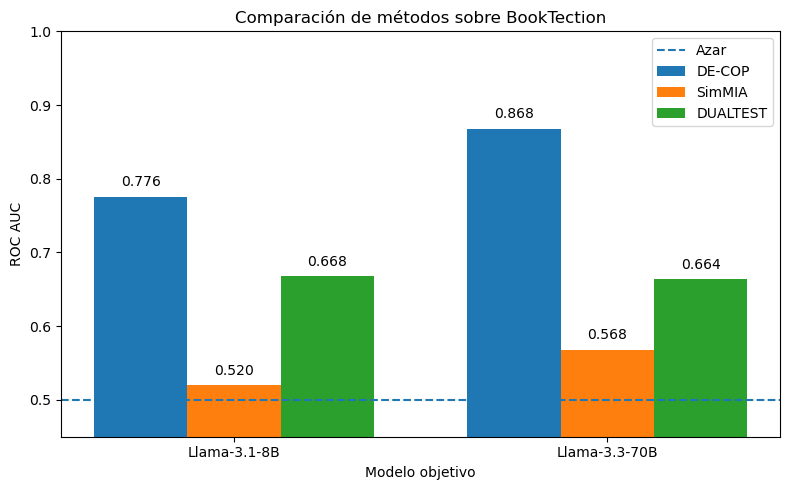

PNG: c:\Users\isiva\OneDrive\Escritorio\Ingenieria de software\NLP_Proyecto_Final\simmia_decop\figures\auc_booktection_three_methods.png
PDF: c:\Users\isiva\OneDrive\Escritorio\Ingenieria de software\NLP_Proyecto_Final\simmia_decop\figures\auc_booktection_three_methods.pdf


In [5]:

models = auc_summary["Modelo"]
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x - width,
    auc_summary["DE-COP"],
    width,
    label="DE-COP",
)

bars2 = ax.bar(
    x,
    auc_summary["SimMIA"],
    width,
    label="SimMIA",
)

bars3 = ax.bar(
    x + width,
    auc_summary["DUALTEST"],
    width,
    label="DUALTEST",
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    label="Azar",
)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("ROC AUC")
ax.set_xlabel("Modelo objetivo")
ax.set_title("Comparación de métodos sobre BookTection")
ax.set_ylim(0.45, 1.0)
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

plt.tight_layout()

png_path = FIGURES_DIR / "auc_booktection_three_methods.png"
pdf_path = FIGURES_DIR / "auc_booktection_three_methods.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("PNG:", png_path)
print("PDF:", pdf_path)


## Comparación de MAE sobre BookTection

In [6]:

mae_summary = pd.DataFrame([
    {
        "Modelo": "Llama-3.1-8B",
        "DE-COP": float(decop_8["mean_absolute_error"]),
        "SimMIA": float(simmia_8["mean_absolute_error"]),
        "DUALTEST": float(dualtest_book_8["mae"]),
    },
    {
        "Modelo": "Llama-3.3-70B",
        "DE-COP": float(decop_70["mean_absolute_error"]),
        "SimMIA": float(simmia_70["mean_absolute_error"]),
        "DUALTEST": float(dualtest_book_70["mae"]),
    },
])

display(mae_summary)

mae_summary.to_csv(
    FIGURES_DIR / "booktection_mae_methods_summary.csv",
    index=False,
)


,Modelo,DE-COP,SimMIA,DUALTEST
0,Llama-3.1-8B,0.3575,0.494606,0.477837
1,Llama-3.3-70B,0.2850,0.481854,0.475036


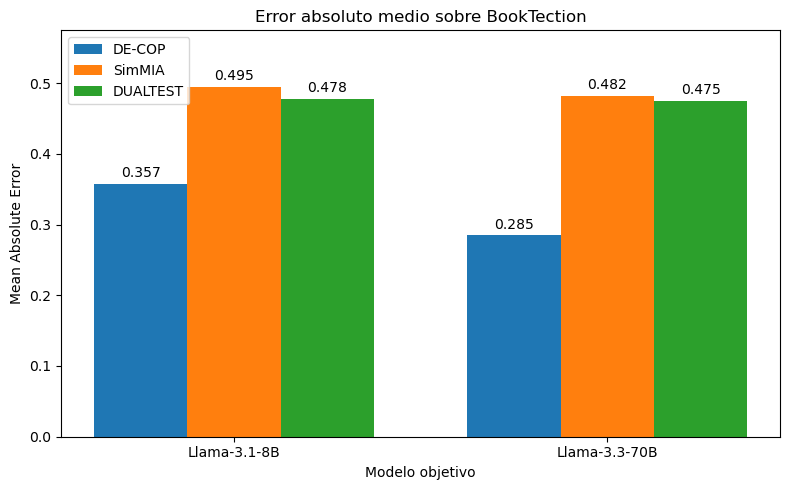

PNG: c:\Users\isiva\OneDrive\Escritorio\Ingenieria de software\NLP_Proyecto_Final\simmia_decop\figures\mae_booktection_three_methods.png
PDF: c:\Users\isiva\OneDrive\Escritorio\Ingenieria de software\NLP_Proyecto_Final\simmia_decop\figures\mae_booktection_three_methods.pdf


In [7]:

models = mae_summary["Modelo"]
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x - width,
    mae_summary["DE-COP"],
    width,
    label="DE-COP",
)

bars2 = ax.bar(
    x,
    mae_summary["SimMIA"],
    width,
    label="SimMIA",
)

bars3 = ax.bar(
    x + width,
    mae_summary["DUALTEST"],
    width,
    label="DUALTEST",
)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Mean Absolute Error")
ax.set_xlabel("Modelo objetivo")
ax.set_title("Error absoluto medio sobre BookTection")
ax.legend()

max_value = mae_summary[["DE-COP", "SimMIA", "DUALTEST"]].to_numpy().max()
ax.set_ylim(0, max_value + 0.08)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

plt.tight_layout()

png_path = FIGURES_DIR / "mae_booktection_three_methods.png"
pdf_path = FIGURES_DIR / "mae_booktection_three_methods.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("PNG:", png_path)
print("PDF:", pdf_path)


## Tabla general de los tres métodos

In [8]:

comparison_df = pd.DataFrame([
    {
        "Método": "DE-COP",
        "Modelo": "Llama-3.1-8B",
        "Dataset": "BookTection",
        "MAE": float(decop_8["mean_absolute_error"]),
        "ROC AUC": float(decop_8["auc"]),
        "TPR@5%FPR": (
            float(decop_8["tpr_at_5_fpr"])
            if "tpr_at_5_fpr" in decop_8.index
            else np.nan
        ),
    },
    {
        "Método": "SimMIA",
        "Modelo": "Llama-3.1-8B",
        "Dataset": "BookTection",
        "MAE": float(simmia_8["mean_absolute_error"]),
        "ROC AUC": float(simmia_8["auc"]),
        "TPR@5%FPR": (
            float(simmia_8["tpr_at_5_fpr"])
            if "tpr_at_5_fpr" in simmia_8.index
            else np.nan
        ),
    },
    {
        "Método": "DUALTEST",
        "Modelo": "Llama-3.1-8B",
        "Dataset": "BookTection",
        "MAE": float(dualtest_book_8["mae"]),
        "ROC AUC": float(dualtest_book_8["roc_auc"]),
        "TPR@5%FPR": np.nan,
    },
    {
        "Método": "DE-COP",
        "Modelo": "Llama-3.3-70B",
        "Dataset": "BookTection",
        "MAE": float(decop_70["mean_absolute_error"]),
        "ROC AUC": float(decop_70["auc"]),
        "TPR@5%FPR": (
            float(decop_70["tpr_at_5_fpr"])
            if "tpr_at_5_fpr" in decop_70.index
            else np.nan
        ),
    },
    {
        "Método": "SimMIA",
        "Modelo": "Llama-3.3-70B",
        "Dataset": "BookTection",
        "MAE": float(simmia_70["mean_absolute_error"]),
        "ROC AUC": float(simmia_70["auc"]),
        "TPR@5%FPR": (
            float(simmia_70["tpr_at_5_fpr"])
            if "tpr_at_5_fpr" in simmia_70.index
            else np.nan
        ),
    },
    {
        "Método": "DUALTEST",
        "Modelo": "Llama-3.3-70B",
        "Dataset": "BookTection",
        "MAE": float(dualtest_book_70["mae"]),
        "ROC AUC": float(dualtest_book_70["roc_auc"]),
        "TPR@5%FPR": np.nan,
    },
])

display(comparison_df)

comparison_df.to_csv(
    FIGURES_DIR / "booktection_three_methods_complete.csv",
    index=False,
)


,Método,Modelo,Dataset,MAE,ROC AUC,TPR@5%FPR
0,DE-COP,Llama-3.1-8B,BookTection,0.357500,0.77565,NaN
1,SimMIA,Llama-3.1-8B,BookTection,0.494606,0.52010,NaN
2,DUALTEST,Llama-3.1-8B,BookTection,0.477837,0.66800,NaN
3,DE-COP,Llama-3.3-70B,BookTection,0.285000,0.86815,NaN
4,SimMIA,Llama-3.3-70B,BookTection,0.481854,0.56790,NaN
5,DUALTEST,Llama-3.3-70B,BookTection,0.475036,0.66390,NaN


## Resultados adicionales de DUALTEST

In [9]:

dualtest_additional = dualtest_results[
    [
        "dataset_group",
        "model_group",
        "n",
        "mae",
        "brier",
        "log_loss",
        "roc_auc",
        "pr_auc",
    ]
].sort_values(
    ["dataset_group", "model_group"]
)

display(dualtest_additional)

dualtest_additional.to_csv(
    FIGURES_DIR / "dualtest_all_datasets_summary.csv",
    index=False,
)


,dataset_group,model_group,n,mae,brier,log_loss,roc_auc,pr_auc
5,BookTection + SAGE,Llama 3.1 8B,200,0.498270,0.251856,0.697767,0.576950,0.548911
3,BookTection + SAGE,Llama 3.3 70B,200,0.476022,0.237279,0.667656,0.627650,0.634164
4,BookTection comparison,Llama 3.1 8B,200,0.477837,0.233661,0.658213,0.668000,0.678195
2,BookTection comparison,Llama 3.3 70B,200,0.475036,0.235977,0.664034,0.663900,0.660241
1,WikiMIA,Llama 3.1 8B,82,0.468218,0.246803,0.689233,0.540481,0.666113
0,WikiMIA,Llama 3.3 70B,82,0.462427,0.250780,0.721103,0.559772,0.645187



## Nota sobre TPR@5%FPR

Los resultados resumidos de DUALTEST compartidos para este análisis no incluyen `TPR@5%FPR`. Por ese motivo, la columna queda vacía para DUALTEST y no se inventa ningún valor. Para calcularla harían falta las etiquetas y probabilidades por muestra.
